## Parte 1
###
### 1) Implementar algoritmo White Patch para librarnos de las diferencias de color de iluminación
### 2) Mostrar los resultados obtenidos y analizar las posibles fallas



En solo un caso (wp_blue.jpg) ocurre que el máximo es 255 para todos los canales. En ese caso se toma el percentil 98 para todos los canales y viendo los nuevos valores observamos que el azul es el color predominante (los percentiles 98 de G y R se van a 69 y a 86 respectivamente, y el azul queda en 253). Esto genera factores de corrrección de brillo elevados para los canales G y R y termina generando una imagen alterada mucho más luminosa vs la original.

In [4]:
import os
import sys

# If running in Colab → clone the repo
if 'google.colab' in sys.modules:
    !git clone https://github.com/ivollonoc/VC1.git
    base_path_1 = '/content/VC1/TP1/parte-1'
    base_path_2 = '/content/VC1/TP1/parte-2'

# If running locally (PyCharm, Jupyter, professor's PC)
else:
    base_path_1 = os.path.join(os.getcwd(), 'TP1', 'parte-1')
    base_path_2 = os.path.join(os.getcwd(), 'TP1', 'parte-2')

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\test_blue.png
bmax: 200, gmax: 138, rmax: 165


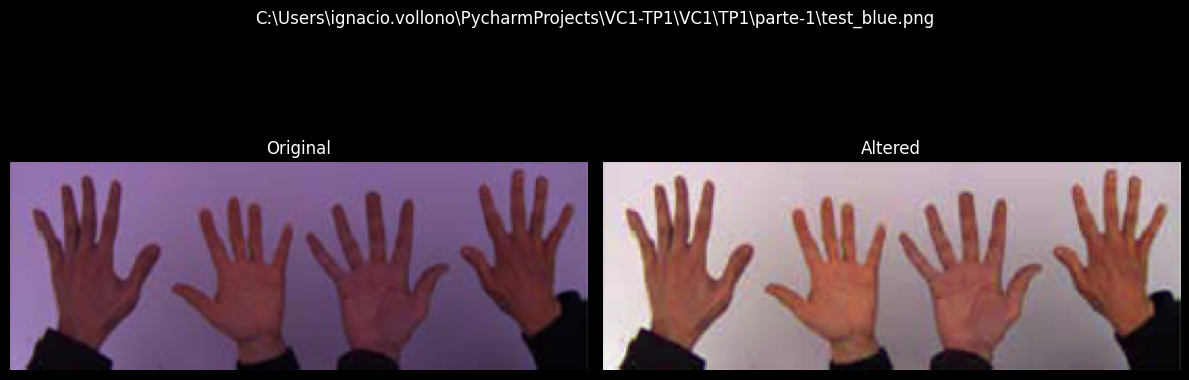

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\test_green.png
bmax: 171, gmax: 250, rmax: 210


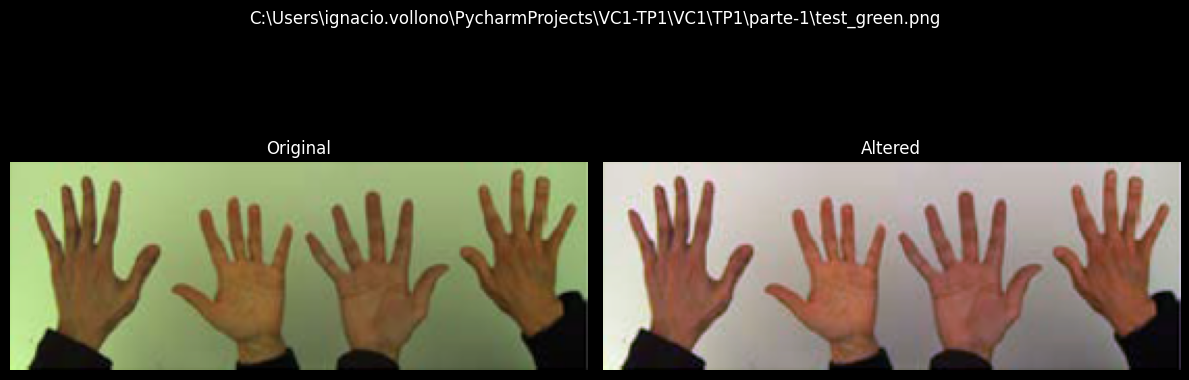

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\test_red.png
bmax: 175, gmax: 157, rmax: 247


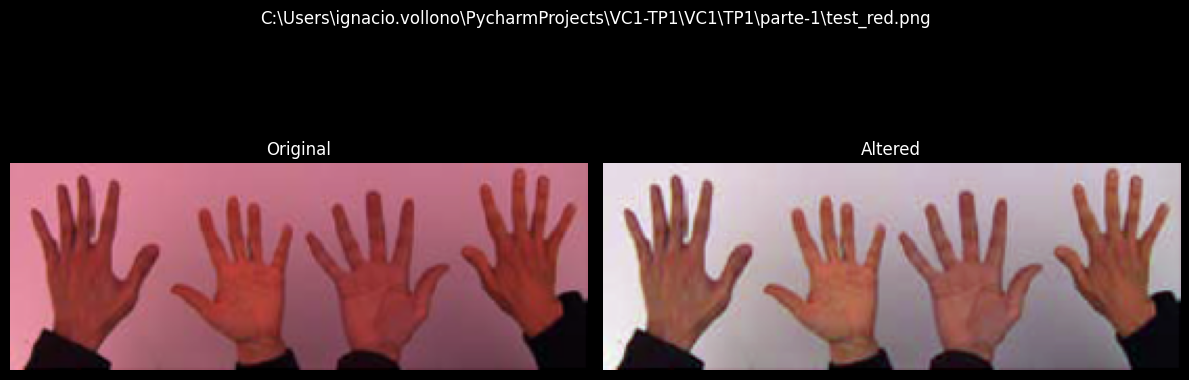

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\wp_blue.jpg
bmax: 255, gmax: 255, rmax: 255. Pasamos a tomar percentiles 98 de cada canal.
bmax: 253.0, gmax: 69.0, rmax: 86.0


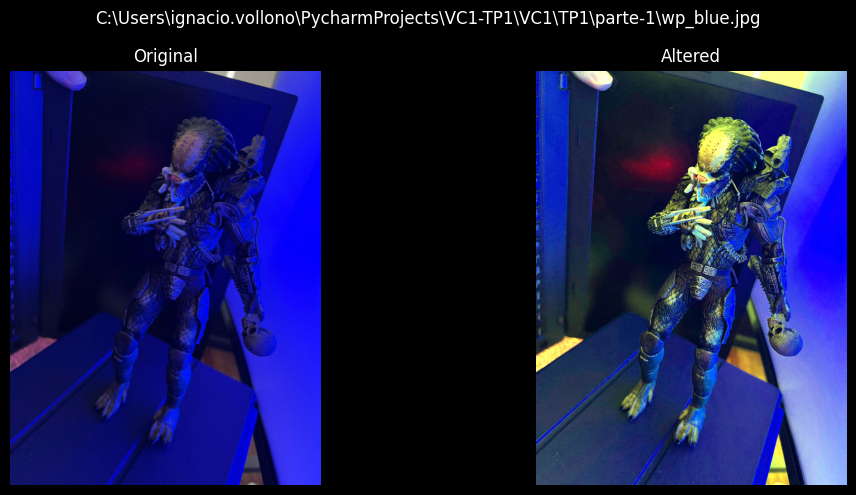

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\wp_green.png
bmax: 155, gmax: 252, rmax: 126


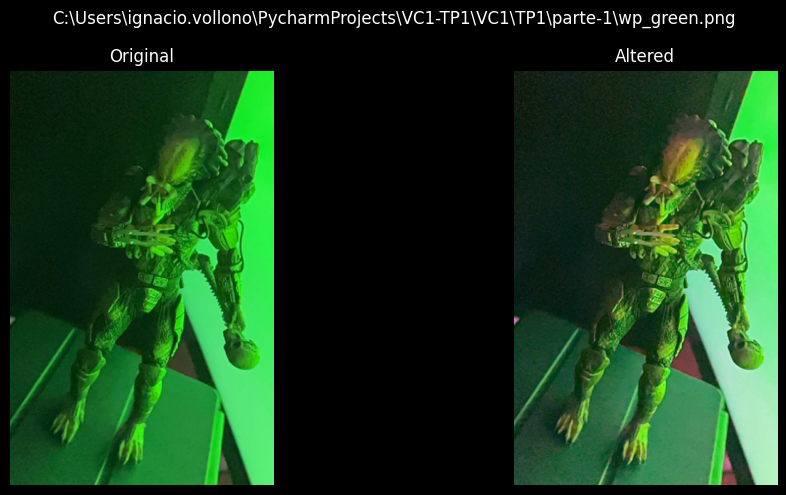

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\wp_green2.jpg
bmax: 172, gmax: 255, rmax: 170


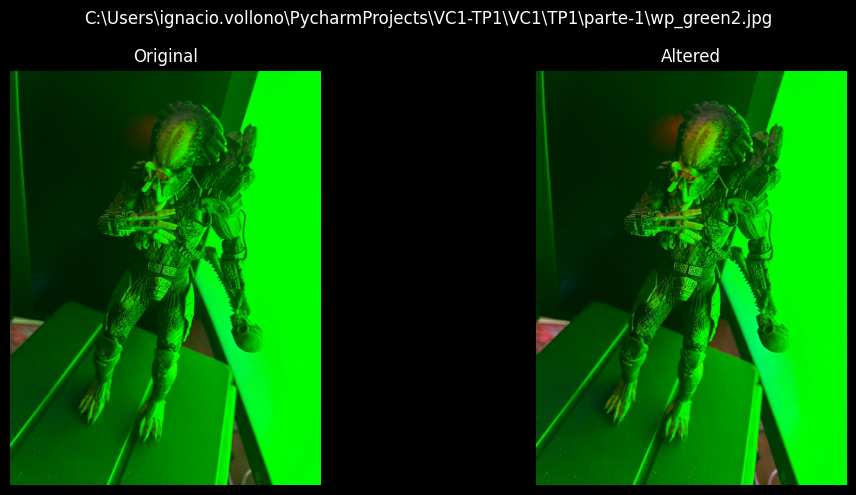

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\wp_red.png
bmax: 122, gmax: 134, rmax: 255


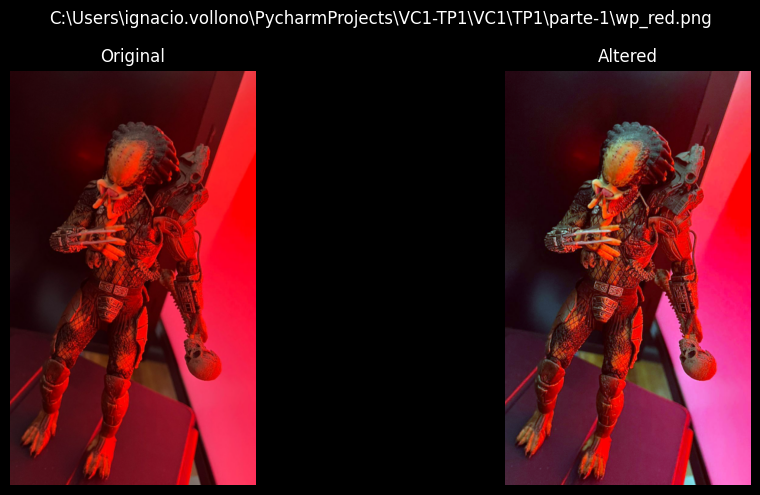

C:\Users\ignacio.vollono\PycharmProjects\VC1-TP1\VC1\TP1\parte-1\wp_red2.jpg
bmax: 203, gmax: 201, rmax: 255


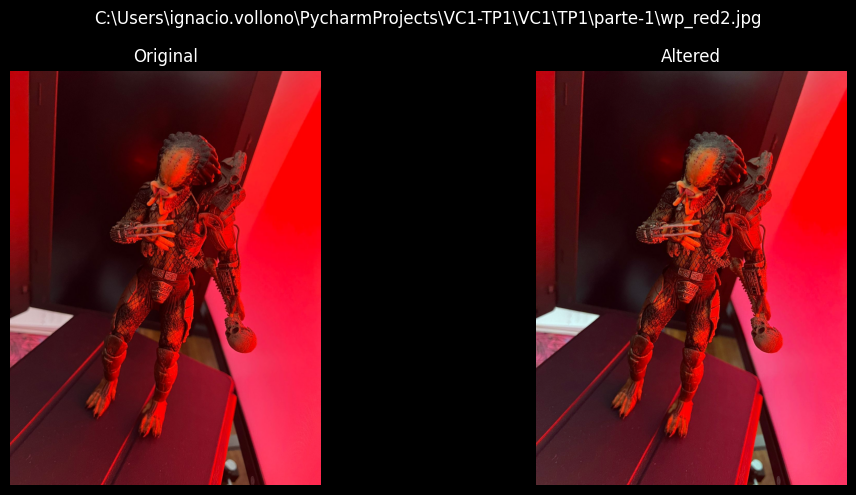

In [5]:
# @title
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import sys

image_files = sorted(
    glob.glob(os.path.join(base_path_1, '*.png')) +
    glob.glob(os.path.join(base_path_1, '*.jpg'))
)


for path in image_files:
    img = cv.imread(path, cv.IMREAD_COLOR)

    b, g, r = cv.split(img)

    bmax = np.max(b)
    gmax = np.max(g)
    rmax = np.max(r)

    print(path.split('/')[-1])
    if bmax == 255 and gmax == 255 and rmax == 255:
        print(f"bmax: {bmax}, gmax: {gmax}, rmax: {rmax}. Pasamos a tomar percentiles 98 de cada canal.")
        bmax = np.percentile(b, 98)
        gmax = np.percentile(g, 98)
        rmax = np.percentile(r, 98)

    bfactor = 255/bmax
    gfactor = 255/gmax
    rfactor = 255/rmax

    print(f"bmax: {bmax}, gmax: {gmax}, rmax: {rmax}")

    b = np.clip(b*bfactor, 0, 255).astype(np.uint8)
    g = np.clip(g*gfactor, 0, 255).astype(np.uint8)
    r = np.clip(r*rfactor, 0, 255).astype(np.uint8)

    img_reconstructed = cv.merge([b, g, r])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(path.split('/')[-1])

    axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(cv.cvtColor(img_reconstructed, cv.COLOR_BGR2RGB))
    axes[1].set_title('Altered')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## Parte 2
###
### 1) Para imágenes im1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas
### 2) Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre sí. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?


Visualizamos las imágenes y graficamos sus histogramas, y llevando los bins al extremo de 255 vemos que estamos ante la misma distribución de cantidad de pixels por valores.
Esto es indicativo de que un histograma por sí mismo no es útil para la detección de imágenes.

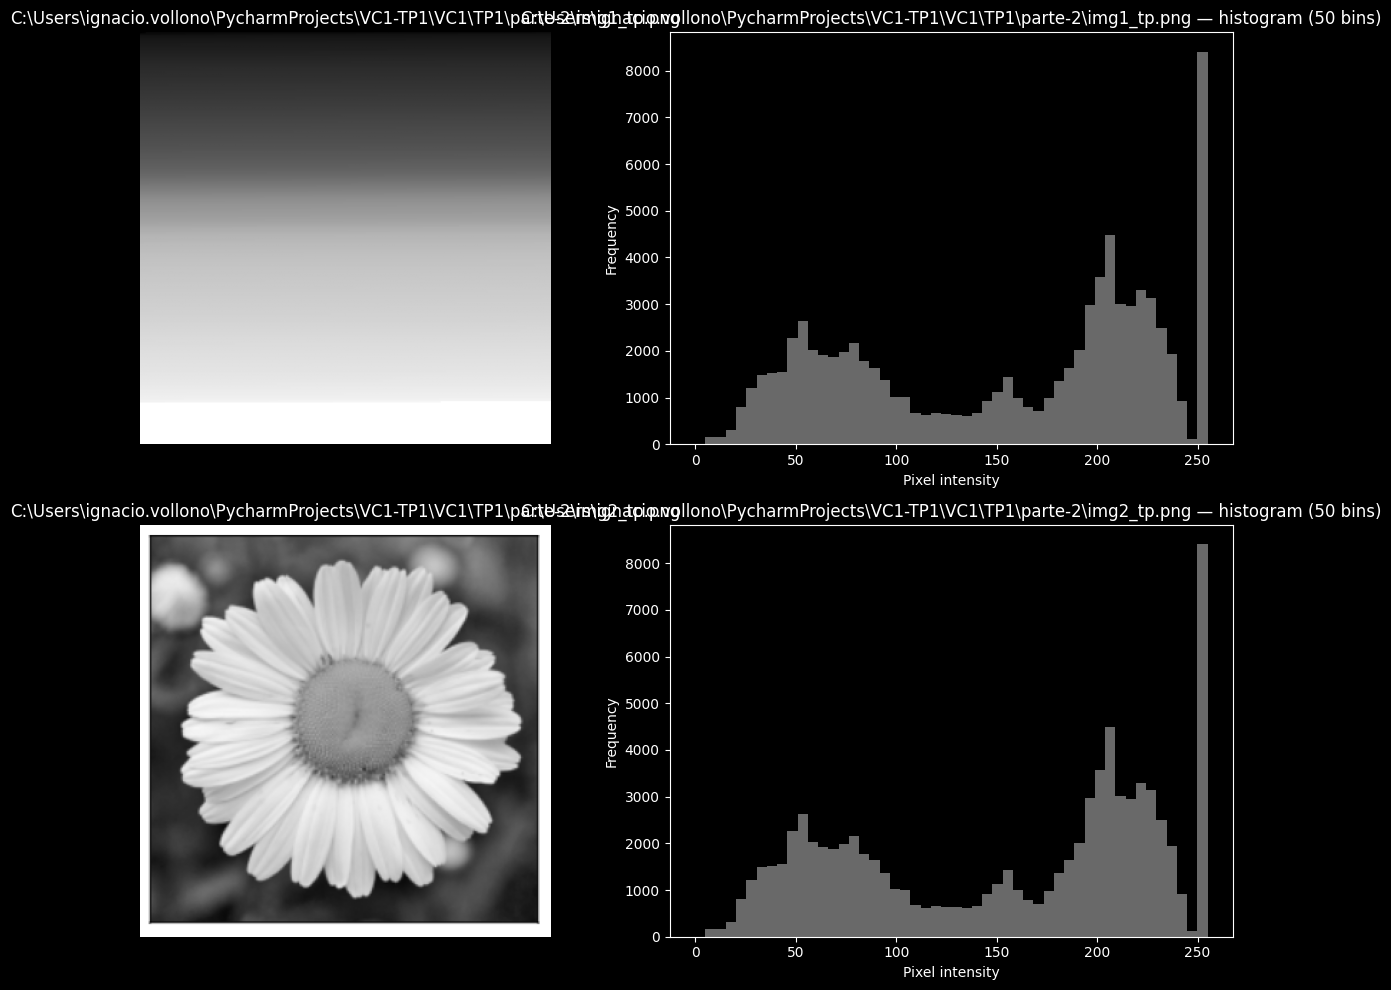

In [11]:
# @title
#image_files2 = sorted(glob.glob('/content/VC1/TP1/parte-2/img1_tp.png') + glob.glob('/content/VC1/TP1/parte-2/img2_tp.png'))

image_files2 = sorted(
    glob.glob(os.path.join(base_path_2, 'img1_tp.png')) +
    glob.glob(os.path.join(base_path_2, 'img2_tp.png'))
)

bins = 50  #parametro a ajustar para #bins

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, path in enumerate(image_files2):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    filename = path.split('/')[-1]

    #columna izquierda: imagen
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(filename)
    axes[i, 0].axis('off')

    #columna derecha: histograma
    axes[i, 1].hist(img.ravel(), bins=bins, range=(0, 255), color='dimgray')
    axes[i, 1].set_title(f'{filename} — histogram ({bins} bins)')
    axes[i, 1].set_xlabel('Pixel intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()